In [ ]:
# train 
# ref: https://chemprop.readthedocs.io/en/latest/cmd.html
import subprocess
# without MDfeautre
n_depths = [2,3,4]
message_hidden_dims = [200,300,400]
ffn_num_layers = [1,2]
ffn_hidden_dims = [200,300,400]
dropouts=[0,0.1,0.2]

# Hyperparameter Tunings
# trial = 0
# for n_depth in n_depths:
#     for message_hidden_dim in message_hidden_dims:
#         for ffn_num_layer in ffn_num_layers:
#             for ffn_hidden_dim in ffn_hidden_dims:
#                 for dropout in dropouts:
#                     command = f"chemprop train --data-path 070324_chemprop_addon.csv --task-type regression --epochs 1000 --num-folds 5 --split CV --save-smiles-splits"
#                     print(trial,command)
#                     trial+=1
#                     subprocess.run(command, shell=True)

# default
# !chemprop train --data-path 062524_chemprop_addon_modifiedF.csv --atom-features-path MDFeatureGen/070124_partialcharge.npz --task-type regression --epochs 1000 --ensemble-size 5 --save-smiles-splits
!chemprop train \
    --data-path 071524_chemprop.csv \
    --task-type regression \
    --epochs 1000 \
    --ensemble-size 5 \
    --batch-size 64 \
    --depth 3 \
    --message-hidden-dim 300 \
    --ffn-num-layers 1 \
    --ffn-hidden-dim 300 \
    --dropout 0 \
    --save-smiles-splits \


    # hyperparameters
    
    # MD feature
    # --atom-features-path MDFeatureGen/070124_partialcharge_sigma_epsilon.npz \
    # MD descriptor
    # --descriptors-path MDFeatureGen/070224_surface_area_head_tail.npz \



2025-03-06T16:07:50 - INFO:chemprop.cli.main - Running in mode 'train' with args: {'smiles_columns': None, 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'molecule_featurizers': None, 'descriptors_path': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'config_path': None, 'data_path': PosixPath('071524_chemprop.csv'), 'output_dir': None, 'remove_checkpoints': False, 'checkpoint': None, 'freeze_encoder': False, 'model_frzn': None, 'frzn_ffn_layers': 0, 'ensemble_size': 5, 'message_hidden_dim': 300, 'message_bias': False, 'depth': 3, 'undirected': False, 'dropout': 0.0, 'mpn_shared': False, 'activation': 'RELU', 'aggregation': 'norm'

In [2]:
# file scan
import os

def scan_files_in_folders(folders):
    models = []
    for folder in folders:
        print(f"Scanning folder: {folder}")
        for root, _, files in os.walk(folder):
            for file in files:
                if 'last' in file:
                    print(os.path.join(root, file))
                    models.append(os.path.join(root, file))
    return models

# List of folders to scan
dir_name = 'chemprop_training/071524_chemprop/2024-12-10T21-41-09'
folders_to_scan = [dir_name]

models = scan_files_in_folders(folders_to_scan)


Scanning folder: chemprop_training/071524_chemprop/2024-12-10T21-41-09
chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_1/checkpoints/last.ckpt
chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_3/checkpoints/last.ckpt
chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_2/checkpoints/last.ckpt
chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_4/checkpoints/last.ckpt
chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_0/checkpoints/last.ckpt


In [6]:
# prediction (automated)
test_csv = 'smiles.csv'
xlsx = '071524_chemprop_gammacmc_realgammamaxpure.xlsx'
import subprocess
import pandas as pd
import numpy as np
for idx, model in enumerate(models):
    ########################## chemprop predict ###################################
    print(f'predict: {model}')
    command = f"chemprop predict --test-path {test_csv} --model-path {model} --preds-path preds{idx}.csv" #--atom-features-path MDFeatureGen/070124_partialcharge_sigma_epsilon.npz --descriptors-path MDFeatureGen/070224_surface_area_head_tail.npz"
    print(command)
    subprocess.run(command, shell=True)
    ########################## end ###################################
    
    # read pred_csv
    df_pred = pd.read_csv(f'preds{idx}.csv')
    # rename the columns
    pred_0 = np.mean(df_pred['pred_0']) # supposed to be 1e-6 order
    pred_1 = np.mean(df_pred['pred_1']) # supposed to be > 0
    pred_2 = np.mean(df_pred['pred_2']) # supposed to be < 0
    rename=[]
    for pred in [pred_0, pred_1, pred_2]:
        if pred < 1e-4 and pred>0:
            rename.append('pred_0')
            continue
        if pred > 0 and pred > 1e-4 :
            rename.append('pred_1')
            continue
        if pred < 0 :
            rename.append('pred_2')
            continue
    df_pred = df_pred.rename(columns={'0':'smiles','pred_0': rename[0], 'pred_1': rename[1], 'pred_2': rename[2]})
    
    # add to xlsx file
    df_xlsx =  pd.read_excel(xlsx)
    df_xlsx['pred_0_m'+str(idx)]=df_pred['pred_0']
    df_xlsx['pred_1_m'+str(idx)]=df_pred['pred_1']
    df_xlsx['pred_2_m'+str(idx)]=df_pred['pred_2']
    df_xlsx.to_excel(xlsx,index=False)

# Create a list of column names to calculate the mean
columns_to_average0 = ['pred_0_m' + str(idx) for idx in range(5)]
columns_to_average1 = ['pred_1_m' + str(idx) for idx in range(5)]
columns_to_average2 = ['pred_2_m' + str(idx) for idx in range(5)]

# Add the new column by calculating the mean across the specified columns
df_xlsx['pred_0'] = df_xlsx[columns_to_average0].mean(axis=1)
df_xlsx['pred_1'] = df_xlsx[columns_to_average1].mean(axis=1)
df_xlsx['pred_2'] = df_xlsx[columns_to_average2].mean(axis=1)
df_xlsx.to_excel(xlsx,index=False)


predict: chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_1/checkpoints/last.ckpt
chemprop predict --test-path smiles.csv --model-path chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_1/checkpoints/last.ckpt --preds-path preds0.csv


2024-12-10T21:54:04 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': None, 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'molecule_featurizers': None, 'descriptors_path': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'test_path': PosixPath('smiles.csv'), 'output': PosixPath('preds0.csv'), 'drop_extra_columns': False, 'model_paths': [PosixPath('chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_1/checkpoints/last.ckpt')], 'cal_path': None, 'uncertainty_method': 'none', 'calibration_method': None, 'evaluation_methods': None, 'uncertainty_dropout_p': 0.1, 'dropout_sampling_size': 10, 'cali

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 23.49it/s]
predict: chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_3/checkpoints/last.ckpt
chemprop predict --test-path smiles.csv --model-path chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_3/checkpoints/last.ckpt --preds-path preds1.csv


2024-12-10T21:54:07 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': None, 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'molecule_featurizers': None, 'descriptors_path': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'test_path': PosixPath('smiles.csv'), 'output': PosixPath('preds1.csv'), 'drop_extra_columns': False, 'model_paths': [PosixPath('chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_3/checkpoints/last.ckpt')], 'cal_path': None, 'uncertainty_method': 'none', 'calibration_method': None, 'evaluation_methods': None, 'uncertainty_dropout_p': 0.1, 'dropout_sampling_size': 10, 'cali

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 23.62it/s]
predict: chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_2/checkpoints/last.ckpt
chemprop predict --test-path smiles.csv --model-path chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_2/checkpoints/last.ckpt --preds-path preds2.csv


...

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 24.01it/s]
predict: chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_4/checkpoints/last.ckpt
chemprop predict --test-path smiles.csv --model-path chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_4/checkpoints/last.ckpt --preds-path preds3.csv


2024-12-10T21:54:12 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': None, 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'molecule_featurizers': None, 'descriptors_path': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'test_path': PosixPath('smiles.csv'), 'output': PosixPath('preds3.csv'), 'drop_extra_columns': False, 'model_paths': [PosixPath('chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_4/checkpoints/last.ckpt')], 'cal_path': None, 'uncertainty_method': 'none', 'calibration_method': None, 'evaluation_methods': None, 'uncertainty_dropout_p': 0.1, 'dropout_sampling_size': 10, 'cali

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 22.88it/s]
predict: chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_0/checkpoints/last.ckpt
chemprop predict --test-path smiles.csv --model-path chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_0/checkpoints/last.ckpt --preds-path preds4.csv


2024-12-10T21:54:15 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': None, 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'molecule_featurizers': None, 'descriptors_path': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'test_path': PosixPath('smiles.csv'), 'output': PosixPath('preds4.csv'), 'drop_extra_columns': False, 'model_paths': [PosixPath('chemprop_training/071524_chemprop/2024-12-10T21-41-09/model_0/checkpoints/last.ckpt')], 'cal_path': None, 'uncertainty_method': 'none', 'calibration_method': None, 'evaluation_methods': None, 'uncertainty_dropout_p': 0.1, 'dropout_sampling_size': 10, 'cali

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 23.85it/s]


SurfaceExcess
train
R-squared: 0.8649311464032043
RMSE: 0.7194574113793892
MAE: 0.4272773436521592
test
R-squared: 0.7939952454137056
RMSE: 1.1421129712107256
MAE: 0.7653130812630362
gamma CMC
train
R-squared: 0.9331106103705762
RMSE: 1.9177574435680471
MAE: 1.1224934216360174
test
R-squared: 0.9102413812977113
RMSE: 2.548709251144937
MAE: 2.188055707334164
LogCMC
train
R-squared: 0.9426994732550739
RMSE: 0.22569551122054768
MAE: 0.14791574684869507
test
R-squared: 0.9596025993580809
RMSE: 0.1812106844290288
MAE: 0.15136680077368275


Text(0, 0.5, 'Predicted logCMC (M)')

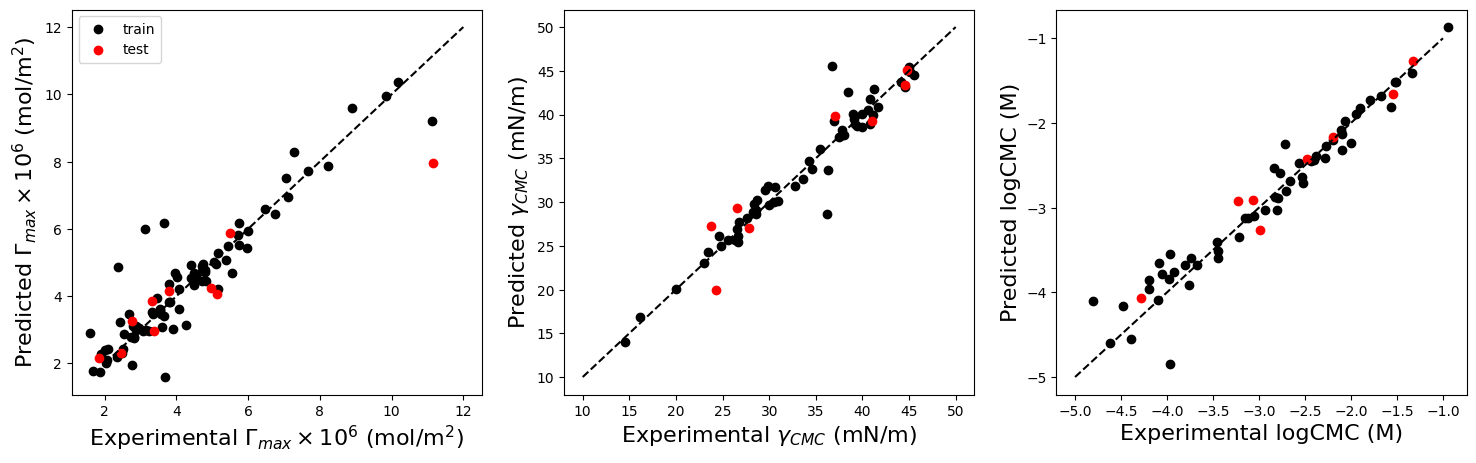

In [8]:
# metrics
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_excel("071524_chemprop_gammacmc_realgammamaxpure.xlsx")
test_df = pd.read_csv(dir_name + '/model_0/test_predictions.csv')
def parityplot(y_true,y_pred,color,label,ax):
    # Calculate R²
    r2 = r2_score(y_true, y_pred)
    print(f'R-squared: {r2}')

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse}')

    # Calculate MAE
    mae = mean_absolute_error(y_true, y_pred)
    print(f'MAE: {mae}')

    ax.scatter(y_true,y_pred,color=color,label=label)

    ax.set_xlabel('y_true')
    ax.set_ylabel('y_pred')


df_train = df[~df['smiles'].isin(test_df['smiles'])]
df_test = df[df['smiles'].isin(test_df['smiles'])]

fig, ax = plt.subplots(1,3,figsize=(18,5))
#'SurfaceExcess'
print('SurfaceExcess')
print('train')
y_true = df_train['SurfaceExcess (mol/m2)'].to_numpy() 
y_pred = df_train['pred_0'].to_numpy()
parityplot(y_true*1e6,y_pred*1e6,'k','train',ax[0])
print('test')
y_true = df_test['SurfaceExcess (mol/m2)'].to_numpy()
y_pred = df_test['pred_0'].to_numpy()
parityplot(y_true*1e6,y_pred*1e6,'r','test',ax[0])
ax[0].plot([2,12],[2,12],'--k')

ax[0].legend()
ax[0].set_xlabel(r'Experimental $\Gamma_{max}\times 10^6$ (mol/m$^2$)',fontsize=16)
ax[0].set_ylabel(r'Predicted $\Gamma_{max}\times 10^6$ (mol/m$^2$)',fontsize=16)

# gamma_cmc
print('gamma CMC')
print('train')
df_train_CMC = df_train.dropna(subset=['Gamma_cmc (mN/m)'])
df_test_CMC = df_test.dropna(subset=['Gamma_cmc (mN/m)'])
y_true = df_train_CMC['Gamma_cmc (mN/m)'].to_numpy()
y_pred = df_train_CMC['pred_1'].to_numpy()
parityplot(y_true,y_pred,'k','train',ax[1])
print('test')
y_true = df_test_CMC['Gamma_cmc (mN/m)'].to_numpy()
y_pred = df_test_CMC['pred_1'].to_numpy()
parityplot(y_true,y_pred,'r','test',ax[1])
ax[1].plot([10,50],[10,50],'--k')
# ax[2].set_title('logCMC')
ax[1].set_xlabel(r'Experimental $\gamma_{CMC}$ (mN/m)',fontsize=16)
ax[1].set_ylabel(r'Predicted $\gamma_{CMC}$ (mN/m)',fontsize=16)

# LogCMC
print('LogCMC')
print('train')
df_train_CMC = df_train.dropna(subset=['LogCMC (M)'])
df_test_CMC = df_test.dropna(subset=['LogCMC (M)'])
y_true = df_train_CMC['LogCMC (M)'].to_numpy()
y_pred = df_train_CMC['pred_2'].to_numpy()
parityplot(y_true,y_pred,'k','train',ax[2])
print('test')
y_true = df_test_CMC['LogCMC (M)'].to_numpy()
y_pred = df_test_CMC['pred_2'].to_numpy()
parityplot(y_true,y_pred,'r','test',ax[2])
ax[2].plot([-5,-1],[-5,-1],'--k')
# ax[2].set_title('logCMC')
ax[2].set_xlabel('Experimental logCMC (M)',fontsize=16)
ax[2].set_ylabel('Predicted logCMC (M)',fontsize=16)

